## 1. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances,
)
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

BASE_DIR  = os.path.abspath("..")
DATA_DIR  = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(PLOTS_DIR, exist_ok=True)

RANDOM_STATE = 42

## 2. Load Data

In [2]:
X_raw = pd.read_csv(os.path.join(DATA_DIR, "executions_features_raw.csv"))

meta = pd.read_csv(os.path.join(DATA_DIR, "executions_meta.csv")).reset_index(drop=True)
assert len(X_raw) == len(meta), "Row mismatch between feature matrix and meta"

print(f"Feature matrix : {X_raw.shape}")
print(f"Meta columns   : {list(meta.columns)}")
print(f"Nulls in X     : {X_raw.isnull().sum().sum()}")

Feature matrix : (9400, 23)
Meta columns   : ['program_id', 'execution_id', 'suggestion_id', 'source_path', 'source_hash', 'pattern', 'severity', 'severity_ordinal', 'detector_family', 'score_dimension', 'complexity_class', 'complexity_ordinal', 'impact_score', 'co_occurring_patterns', 'source_lines', 'score', 'efficiency_complexity_score', 'quality_score', 'maintainability_score']
Nulls in X     : 0


## 3. Program level Holdout Split

In [3]:
assert "program_id" in meta.columns, "program_id is required for program-level split"
program_ids = np.array(sorted(meta["program_id"].unique()))
cluster_programs, holdout_programs = train_test_split(
    program_ids, test_size=0.20, random_state=RANDOM_STATE
)

cluster_program_set = set(cluster_programs)
holdout_program_set = set(holdout_programs)

idx_cluster = np.flatnonzero(meta["program_id"].isin(cluster_program_set).values)
idx_holdout = np.flatnonzero(meta["program_id"].isin(holdout_program_set).values)

assert len(idx_cluster) + len(idx_holdout) == len(X_raw), "Invalid program-level split"
assert len(np.intersect1d(idx_cluster, idx_holdout)) == 0, "Cluster/holdout overlap"
assert cluster_program_set.isdisjoint(holdout_program_set), "Program overlap"

X_cluster_raw = X_raw.iloc[idx_cluster]
X_holdout_raw = X_raw.iloc[idx_holdout]

print(f"Clustering programs : {len(cluster_programs):,} (80%)")
print(f"Holdout programs    : {len(holdout_programs):,} (20%)")
print(f"Clustering rows     : {len(X_cluster_raw):,}")
print(f"Holdout rows        : {len(X_holdout_raw):,}")

Clustering programs : 1,600 (80%)
Holdout programs    : 400 (20%)
Clustering rows     : 7,515
Holdout rows        : 1,885


## 4. Isolated Scaling & PCA

In [4]:
# 1. Fit scaler ONLY on clustering data
scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster_raw)
X_holdout_scaled = scaler_clust.transform(X_holdout_raw)

# 2. Fit PCA ONLY on scaled clustering data (retain 95% variance)
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_cluster_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Components to reach 95% variance: {n_components_95} (from {X_cluster_scaled.shape[1]})")

# 3. Apply PCA
pca_clust = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_pca_cluster = pca_clust.fit_transform(X_cluster_scaled)
X_pca_holdout = pca_clust.transform(X_holdout_scaled)

# 4. Combine back into full PCA matrix for consistent indexing
X_pca = np.empty((len(X_raw), n_components_95))
X_pca[idx_cluster] = X_pca_cluster
X_pca[idx_holdout] = X_pca_holdout

print(f"Reduced shape: {X_pca.shape}")
print(f"Variance retained: {pca_clust.explained_variance_ratio_.sum()*100:.2f}%")

joblib.dump(scaler_clust, os.path.join(MODELS_DIR, "clustering_scaler.joblib"))
joblib.dump(pca_clust, os.path.join(MODELS_DIR, "clustering_pca.joblib"))
print("✓ Saved clustering scaler & PCA transformers.")

Components to reach 95% variance: 8 (from 23)
Reduced shape: (9400, 8)
Variance retained: 96.43%
✓ Saved clustering scaler & PCA transformers.


## 5. Agglomerative Clustering — Select k via Dendrogram

Using Ward linkage on a random subsample (2,000 rows) for dendrogram readability. Full dataset used for final clustering.

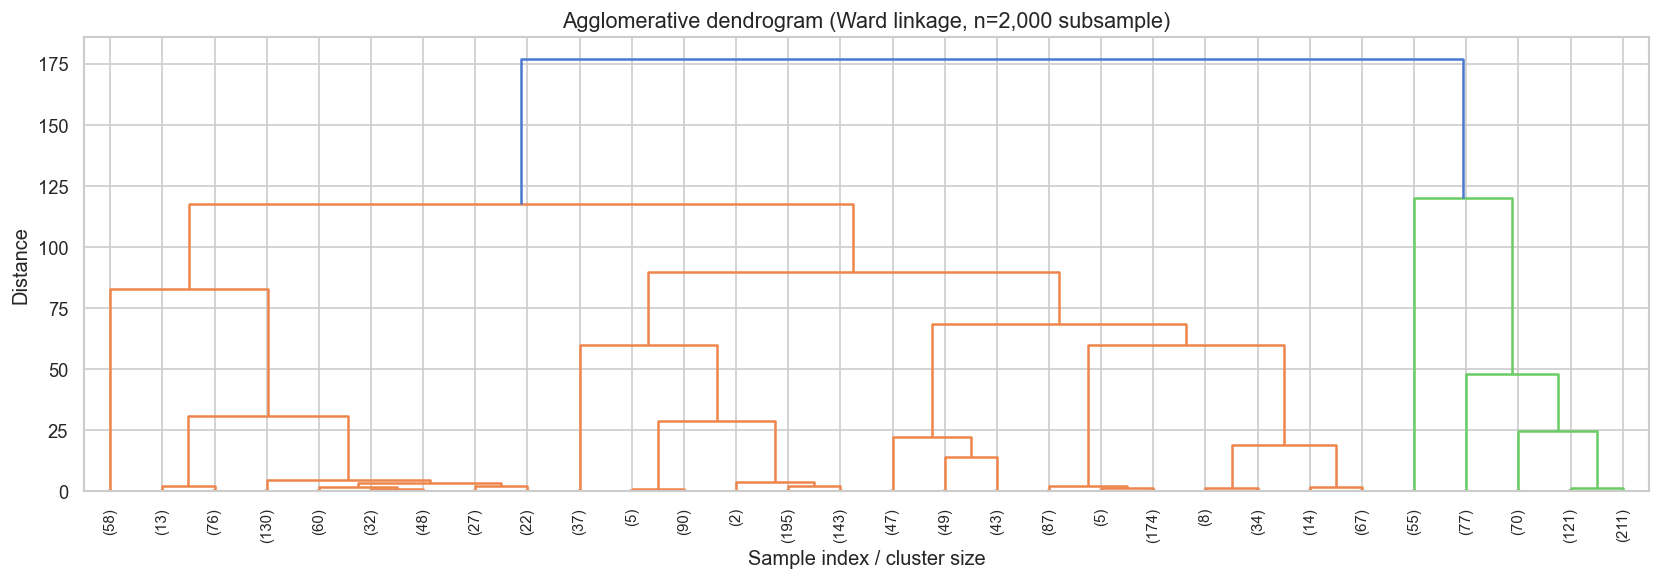


Read the dendrogram: look for the largest vertical gap before merging.
That gap indicates the natural number of clusters.


In [5]:
# Subsample for dendrogram — Ward linkage is O(n²) memory
sample_idx = np.random.choice(len(X_pca_cluster), size=min(2000, len(X_pca_cluster)), replace=False)
X_sample = X_pca_cluster[sample_idx]

Z = linkage(X_sample, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2]),
)
ax.set_title("Agglomerative dendrogram (Ward linkage, n=2,000 subsample)", fontsize=13)
ax.set_xlabel("Sample index / cluster size")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "dendrogram.png"), dpi=150)
plt.show()

print("\nRead the dendrogram: look for the largest vertical gap before merging.")
print("That gap indicates the natural number of clusters.")

In [6]:
last_merges = Z[-15:, 2][::-1]
gaps = np.diff(last_merges) * -1
suggested_k = int(np.argmax(gaps)) + 2

## 6. K-Medoids — k Selection via Silhouette + Davies-Bouldin

Sweep k=2..10. Uses Euclidean distance on PCA-reduced space.

In [7]:
def kmedoids(X, k, max_iter=100, random_state=42):
    """
    Simple PAM-style K-Medoids implementation.
    X: numpy array (n_samples, n_features)
    Returns: labels (n_samples,), medoid_indices (k,)
    """
    rng = np.random.RandomState(random_state)
    n = len(X)

    # Precompute full distance matrix
    D = pairwise_distances(X, metric="euclidean")

    # Init: pick k random medoids
    medoid_idx = rng.choice(n, size=k, replace=False)

    for iteration in range(max_iter):
        # Assign each point to nearest medoid
        labels = np.argmin(D[:, medoid_idx], axis=1)

        new_medoids = np.empty(k, dtype=int)
        for cluster in range(k):
            members = np.where(labels == cluster)[0]
            if len(members) == 0:
                new_medoids[cluster] = medoid_idx[cluster]
                continue
            # New medoid = member with min total distance to all other members
            sub_D = D[np.ix_(members, members)]
            new_medoids[cluster] = members[np.argmin(sub_D.sum(axis=1))]

        if np.array_equal(sorted(new_medoids), sorted(medoid_idx)):
            break
        medoid_idx = new_medoids

    # Final assignment
    labels = np.argmin(D[:, medoid_idx], axis=1)
    return labels, medoid_idx

In [8]:
K_RANGE = range(2, 11)
sil_scores, db_scores, ch_scores = [], [], []

# Subsample for sweep
rng_sub = np.random.RandomState(RANDOM_STATE)
sub_idx = rng_sub.choice(len(X_pca_cluster), size=min(2000, len(X_pca_cluster)), replace=False)
X_sub = X_pca_cluster[sub_idx]

print("Sweeping k on subsample (n=2,000)...")
for k in K_RANGE:
    labels, _ = kmedoids(X_sub, k=k, random_state=RANDOM_STATE)
    sil_scores.append(silhouette_score(X_sub, labels))
    db_scores.append(davies_bouldin_score(X_sub, labels))
    ch_scores.append(calinski_harabasz_score(X_sub, labels))
    print(f" k={k:>2}| Silhouette={sil_scores[-1]:.4f}| Davies-Bouldin={db_scores[-1]:.4f}| Calinski-Harabasz={ch_scores[-1]:.1f}")

Sweeping k on subsample (n=2,000)...
 k= 2| Silhouette=0.3052| Davies-Bouldin=1.3071| Calinski-Harabasz=509.9
 k= 3| Silhouette=0.5035| Davies-Bouldin=0.9836| Calinski-Harabasz=1124.2
 k= 4| Silhouette=0.5012| Davies-Bouldin=1.2261| Calinski-Harabasz=969.7
 k= 5| Silhouette=0.5276| Davies-Bouldin=1.1806| Calinski-Harabasz=941.7
 k= 6| Silhouette=0.6290| Davies-Bouldin=0.8792| Calinski-Harabasz=1538.4
 k= 7| Silhouette=0.5222| Davies-Bouldin=1.0727| Calinski-Harabasz=1412.9
 k= 8| Silhouette=0.5998| Davies-Bouldin=0.9009| Calinski-Harabasz=1748.3
 k= 9| Silhouette=0.4783| Davies-Bouldin=1.0556| Calinski-Harabasz=713.7
 k=10| Silhouette=0.3423| Davies-Bouldin=1.1407| Calinski-Harabasz=637.0


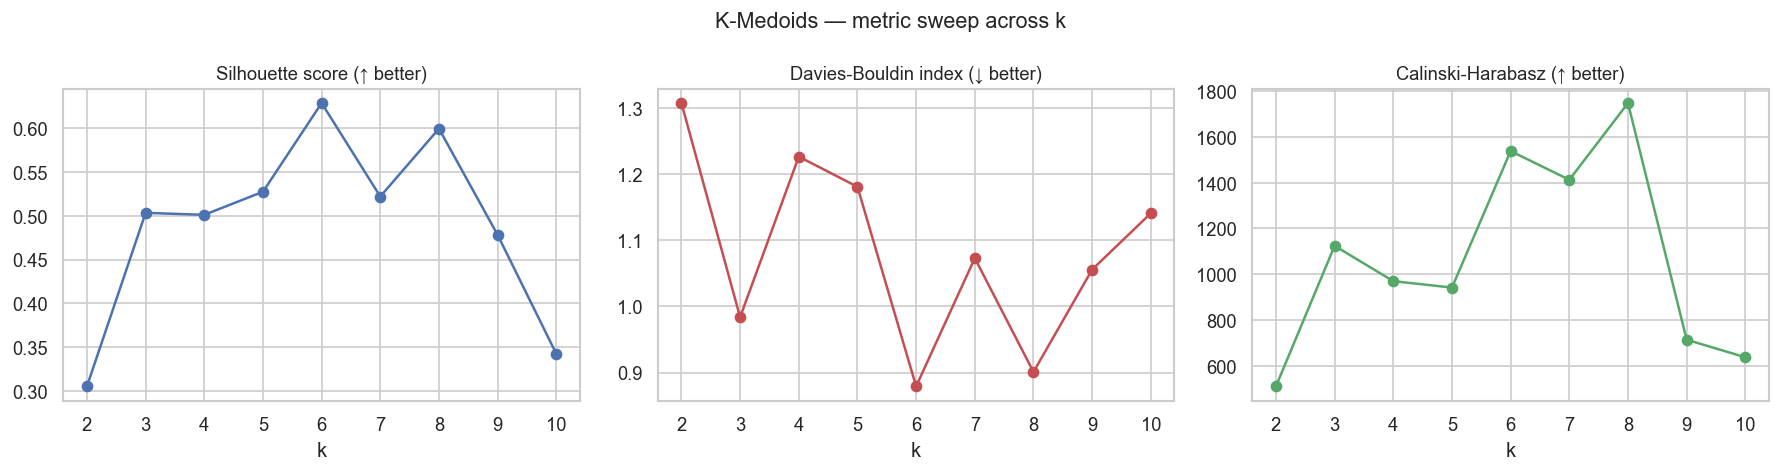

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_list = list(K_RANGE)

# Silhouette — higher is better
axes[0].plot(k_list, sil_scores, marker="o", color="#4C72B0")
axes[0].set_title("Silhouette score (↑ better)", fontsize=11)
axes[0].set_xlabel("k")
axes[0].set_xticks(k_list)

# Davies-Bouldin — lower is better
axes[1].plot(k_list, db_scores, marker="o", color="#C44E52")
axes[1].set_title("Davies-Bouldin index (↓ better)", fontsize=11)
axes[1].set_xlabel("k")
axes[1].set_xticks(k_list)

# Calinski-Harabasz — higher is better
axes[2].plot(k_list, ch_scores, marker="o", color="#55A868")
axes[2].set_title("Calinski-Harabasz (↑ better)", fontsize=11)
axes[2].set_xlabel("k")
axes[2].set_xticks(k_list)

plt.suptitle("K-Medoids — metric sweep across k", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "kmedoids_metric_sweep.png"), dpi=150)
plt.show()

In [10]:
# Select k — agreement across metrics + dendrogram suggestion
best_sil_k = k_list[int(np.argmax(sil_scores))]
best_db_k  = k_list[int(np.argmin(db_scores))]
best_ch_k  = k_list[int(np.argmax(ch_scores))]

print(f"Best k by Silhouette       : {best_sil_k}")
print(f"Best k by Davies-Bouldin   : {best_db_k}")
print(f"Best k by Calinski-Harabasz: {best_ch_k}")
print(f"Dendrogram suggestion      : {suggested_k}")

Best k by Silhouette       : 6
Best k by Davies-Bouldin   : 6
Best k by Calinski-Harabasz: 8
Dendrogram suggestion      : 2


In [11]:
votes = [best_sil_k, best_db_k, best_ch_k, suggested_k]
from collections import Counter
FINAL_K = Counter(votes).most_common(1)[0][0]
print(f"\n→ FINAL_K = {FINAL_K}")


→ FINAL_K = 6


## 7. Final K-Medoids on Program-Level Clustering Split

Hold out entire programs before clustering so downstream classification is evaluated on programs whose suggestions did not define the medoids.

In [12]:
print(f"\nRunning K-Medoids (k={FINAL_K}) on program-level clustering set (n={len(X_pca_cluster):,})...")
cluster_labels_80, medoid_indices = kmedoids(
    X_pca_cluster, k=FINAL_K, random_state=RANDOM_STATE
)

unique, counts = np.unique(cluster_labels_80, return_counts=True)
print("\nCluster size distribution (clustering set):")
for cl, ct in zip(unique, counts):
    print(f"  Cluster {cl}: {ct:,} rows ({ct/len(cluster_labels_80)*100:.1f}%)")

# Nearest medoid assignment for holdout-program rows
medoid_vectors = X_pca_cluster[medoid_indices] 

def assign_to_nearest_medoid(X_new, medoid_vectors):
    """Assign each row in X_new to the index of the nearest medoid."""
    dists = np.linalg.norm(
        X_new[:, np.newaxis, :] - medoid_vectors[np.newaxis, :, :],
        axis=2,
    )  
    return np.argmin(dists, axis=1)


cluster_labels_20 = assign_to_nearest_medoid(X_pca_holdout, medoid_vectors)

print("\nHoldout cluster distribution:")
unique_h, counts_h = np.unique(cluster_labels_20, return_counts=True)
for cl, ct in zip(unique_h, counts_h):
    print(f"  Cluster {cl}: {ct:,} rows")

# Reconstruct aligned full-length cluster label array
final_labels = np.empty(len(X_pca), dtype=int)
final_labels[idx_cluster] = cluster_labels_80
final_labels[idx_holdout] = cluster_labels_20

print(f"\nFull label array shape : {final_labels.shape}")
print(f"Unique clusters        : {np.unique(final_labels)}")



Running K-Medoids (k=6) on program-level clustering set (n=7,515)...

Cluster size distribution (clustering set):
  Cluster 0: 163 rows (2.2%)
  Cluster 1: 1,746 rows (23.2%)
  Cluster 2: 1,600 rows (21.3%)
  Cluster 3: 2,076 rows (27.6%)
  Cluster 4: 1,763 rows (23.5%)
  Cluster 5: 167 rows (2.2%)

Holdout cluster distribution:
  Cluster 0: 37 rows
  Cluster 1: 454 rows
  Cluster 2: 400 rows
  Cluster 3: 524 rows
  Cluster 4: 437 rows
  Cluster 5: 33 rows

Full label array shape : (9400,)
Unique clusters        : [0 1 2 3 4 5]


## 8. Internal Validation — Final Model

In [13]:
sil_final = silhouette_score(X_pca_cluster, cluster_labels_80)
db_final  = davies_bouldin_score(X_pca_cluster, cluster_labels_80)
ch_final  = calinski_harabasz_score(X_pca_cluster, cluster_labels_80)

print("=== Final Model — Internal Validation (clustering set only) ===")
print(f"  Silhouette score     : {sil_final:.4f}  (target > 0.35)")
print(f"  Davies-Bouldin index : {db_final:.4f}  (lower is better)")
print(f"  Calinski-Harabasz    : {ch_final:.1f}  (higher is better)")

if sil_final < 0.25:
    print("\n⚠ Silhouette < 0.25 — clusters are weak. Consider revisiting k or feature set.")
elif sil_final < 0.35:
    print("\n~ Silhouette 0.25–0.35 — reasonable but not strong. Acceptable for this data profile.")
else:
    print("\n✓ Silhouette > 0.35 — clusters are well-separated.")


=== Final Model — Internal Validation (clustering set only) ===
  Silhouette score     : 0.6102  (target > 0.35)
  Davies-Bouldin index : 0.6542  (lower is better)
  Calinski-Harabasz    : 3725.2  (higher is better)

✓ Silhouette > 0.35 — clusters are well-separated.


## 9. External Validation — ARI Against Pattern & Severity Labels

We are **not** optimising for this. It's a sanity check — if ARI is 0.0, the clusters capture something orthogonal to pattern labels (interesting). If ARI is high, clusters closely mirror patterns (expected given `constant_folding` dominance).

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
pattern_encoded  = le.fit_transform(meta["pattern"])
severity_encoded = le.fit_transform(meta["severity"])

ari_pattern  = adjusted_rand_score(pattern_encoded,  final_labels)
ari_severity = adjusted_rand_score(severity_encoded, final_labels)

print("=== External Validation (ARI) ===")
print(f"  ARI vs pattern  : {ari_pattern:.4f}")
print(f"  ARI vs severity : {ari_severity:.4f}")
print()
print("Interpretation:")
print("  ARI = 1.0 → clusters perfectly mirror the label")
print("  ARI = 0.0 → clusters are independent of the label (random agreement)")
print("  ARI < 0  → worse than random")

# Cross-tab: cluster vs pattern
cross = pd.crosstab(
    pd.Series(final_labels, name="cluster"),
    meta["pattern"],
    normalize="index"
).round(2)
print("\nCluster composition by pattern (row-normalized):")
display(cross)

=== External Validation (ARI) ===
  ARI vs pattern  : 0.4519
  ARI vs severity : 0.0288

Interpretation:
  ARI = 1.0 → clusters perfectly mirror the label
  ARI = 0.0 → clusters are independent of the label (random agreement)
  ARI < 0  → worse than random

Cluster composition by pattern (row-normalized):


pattern,constant_folding,dead_code,early_return,expensive_calls,hot_loop,loop_invariant,nested_loops,repeated_computation,string_concat_loop,unused_vars
cluster,,,,,,,,,,
0,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,1.0,0.00
1,0.91,0.0,0.00,0.00,0.00,0.09,0.00,0.00,0.0,0.00
2,1.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00
3,0.00,0.0,0.92,0.00,0.08,0.00,0.00,0.00,0.0,0.00
4,0.36,0.0,0.00,0.09,0.09,0.00,0.09,0.09,0.0,0.27
5,0.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00


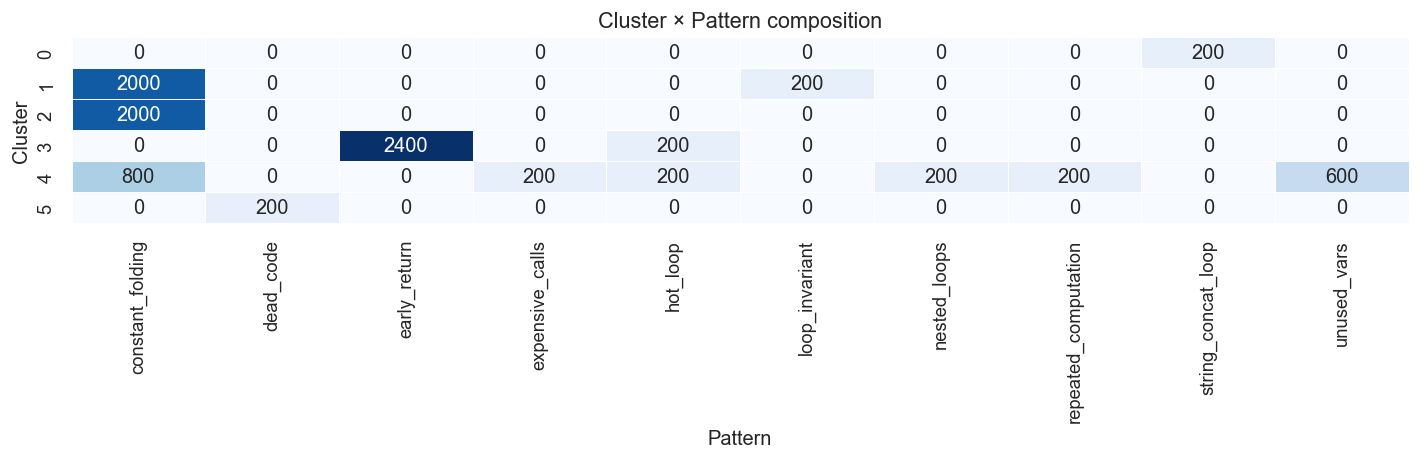

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
cross_raw = pd.crosstab(
    pd.Series(final_labels, name="cluster"),
    meta["pattern"]
)
sns.heatmap(
    cross_raw, ax=ax,
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.4, linecolor="white", cbar=False
)
ax.set_title("Cluster × Pattern composition", fontsize=13)
ax.set_xlabel("Pattern")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_pattern_heatmap.png"), dpi=150)
plt.show()

## 9. Cluster Profiling — Feature Medians per Cluster

Use original (unscaled) features for interpretable medians.

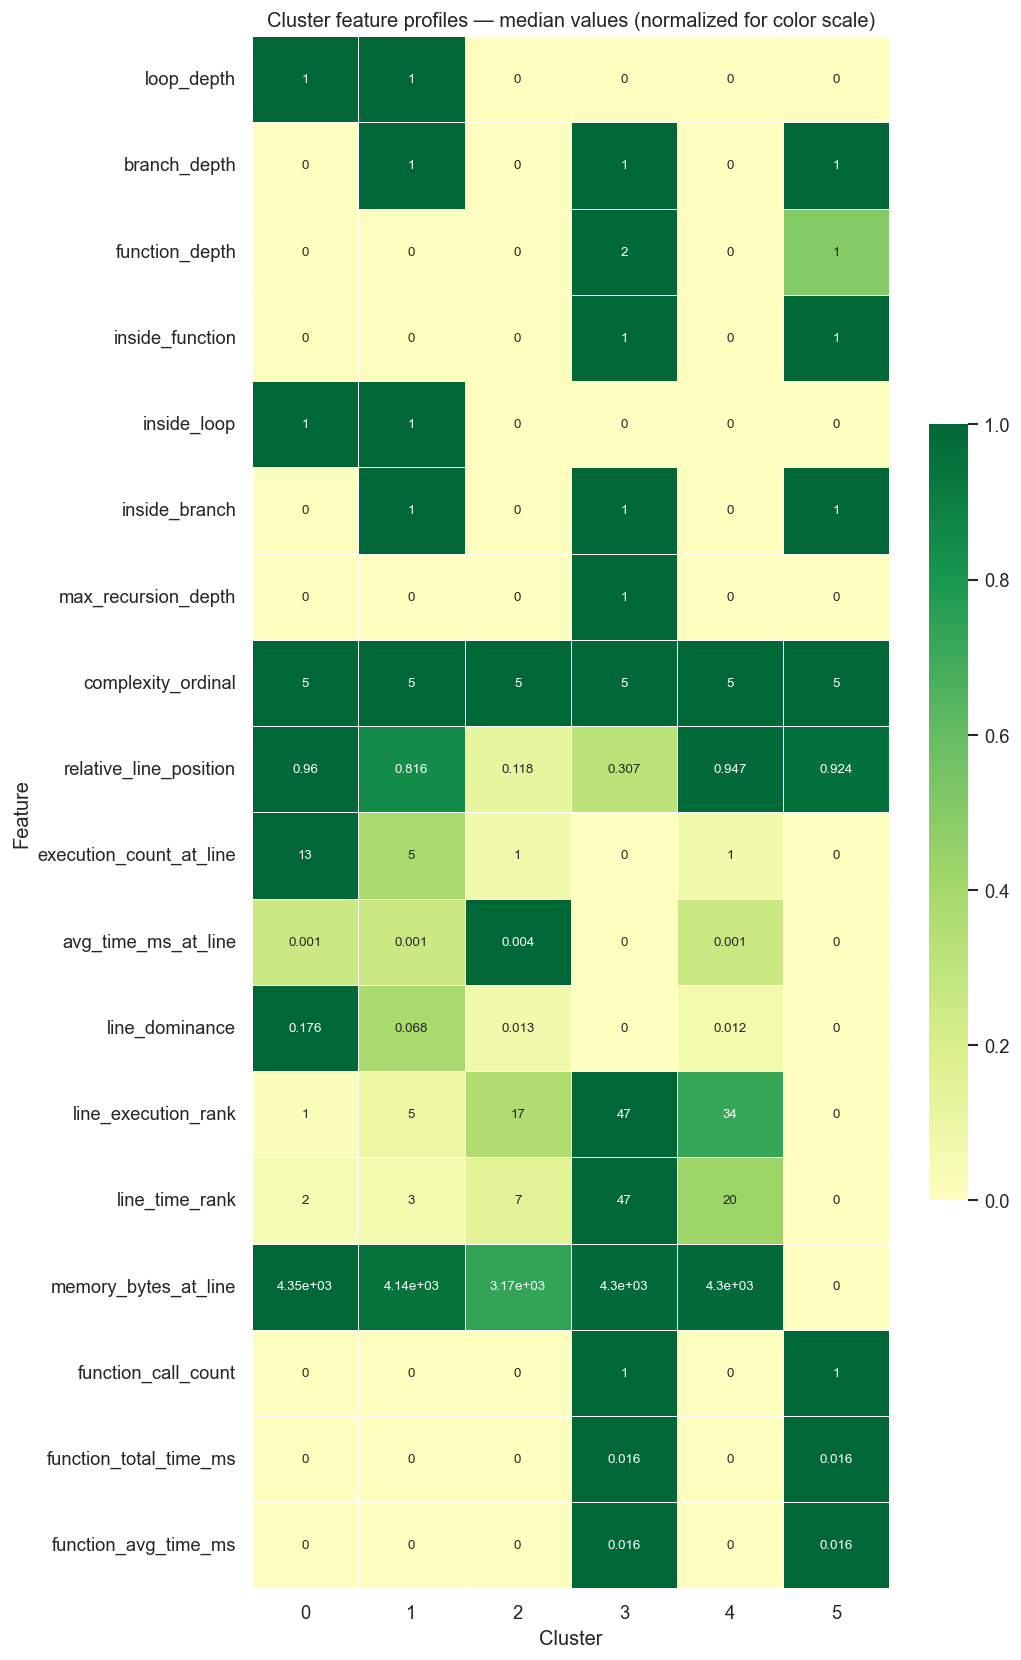

In [16]:
clean = pd.read_csv(os.path.join(DATA_DIR, "executions_clean.csv"))
clean["cluster"] = final_labels
meta["cluster"] = final_labels

profile = clean.groupby("cluster").median(numeric_only=True).T
profile_norm = profile.div(profile.abs().max(axis=1).replace(0, 1), axis=0)

fig, ax = plt.subplots(figsize=(max(8, FINAL_K * 1.5), 14))
sns.heatmap(
    profile_norm, ax=ax,
    annot=profile.round(3), fmt=".3g",
    cmap="RdYlGn", center=0,
    linewidths=0.3, linecolor="white",
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.5},
)
ax.set_title("Cluster feature profiles — median values (normalized for color scale)", fontsize=12)
ax.set_xlabel("Cluster")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_feature_profile.png"), dpi=150)
plt.show()

Severity distribution per cluster (row-normalized):


severity,high,low,medium
cluster,,,
0,0.000,1.000,0.000
1,0.000,0.909,0.091
2,0.000,1.000,0.000
3,0.000,0.923,0.077
4,0.091,0.727,0.182
5,0.000,0.000,1.000



impact_score per cluster:


,median,mean,std
cluster,,,
0,5.0,5.000,0.000
1,2.0,2.545,1.725
2,2.0,2.000,0.000
3,3.0,3.538,1.866
4,3.0,5.364,4.774
5,7.0,7.000,0.000


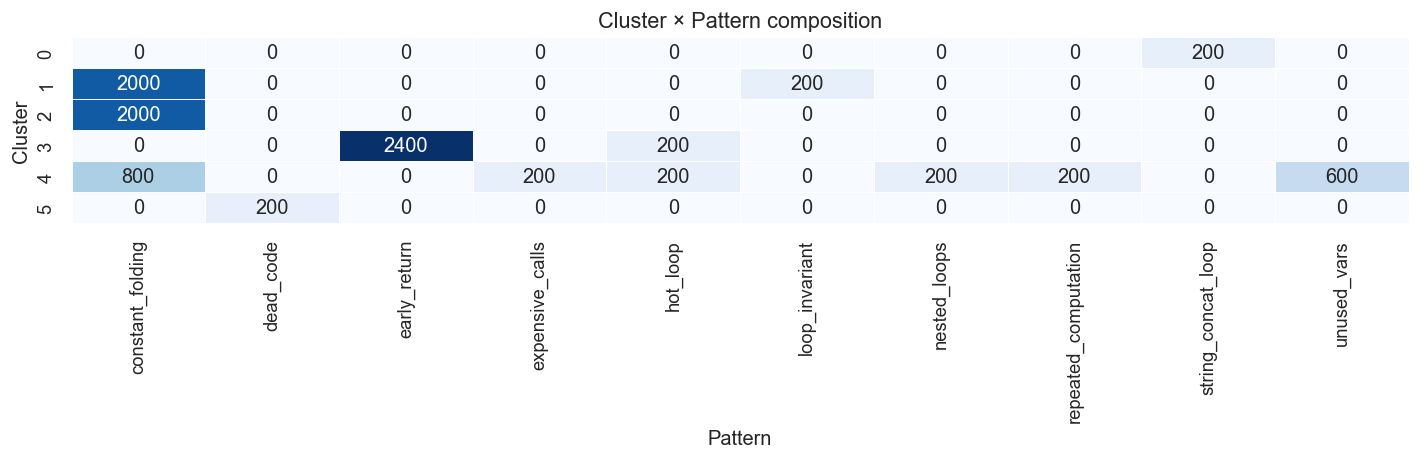

In [17]:
# Severity breakdown per cluster
sev_cross = pd.crosstab(
    meta["cluster"],
    meta["severity"],
    normalize="index"
).round(3)
print("Severity distribution per cluster (row-normalized):")
display(sev_cross)

# Impact score per cluster
impact_profile = meta.groupby("cluster")["impact_score"].agg(["median", "mean", "std"])
print("\nimpact_score per cluster:")
display(impact_profile.round(3))

fig, ax = plt.subplots(figsize=(12, 4))
cross_raw = pd.crosstab(
    pd.Series(final_labels, name="cluster"),
    meta["pattern"]
)
sns.heatmap(
    cross_raw, ax=ax,
    annot=True, fmt="d", cmap="Blues",
    linewidths=0.4, linecolor="white", cbar=False
)
ax.set_title("Cluster × Pattern composition", fontsize=13)
ax.set_xlabel("Pattern")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_pattern_heatmap.png"), dpi=150)
plt.show()

## 10. PCA 2D Visualization

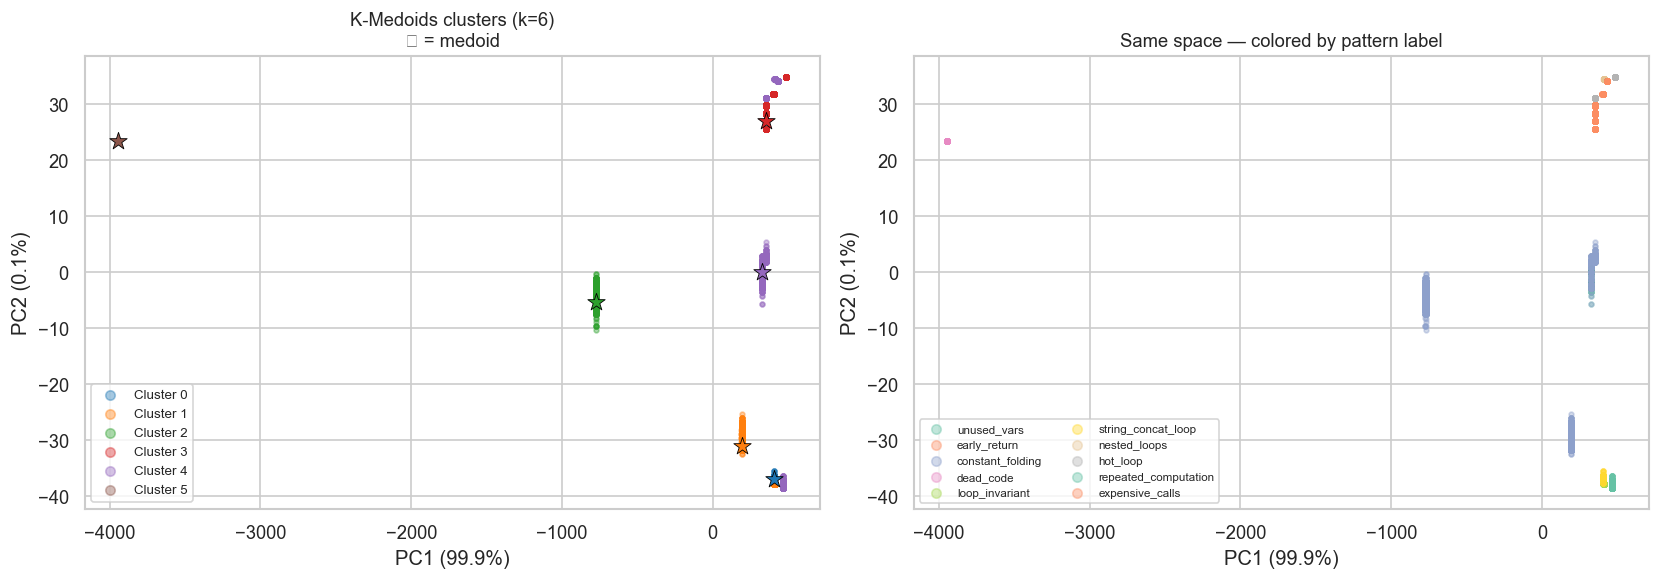

In [18]:
from sklearn.metrics import pairwise_distances

medoid_global_indices = []
for cl in range(FINAL_K):
    mask = final_labels == cl
    X_cl = X_pca[mask] 
    dists = pairwise_distances(X_cl, metric='euclidean').sum(axis=1)
    local_medoid = np.argmin(dists)
    medoid_global_indices.append(np.where(mask)[0][local_medoid])

medoid_global_indices = np.array(medoid_global_indices)

pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d   = pca_2d.fit_transform(X_raw)
var_2d = pca_2d.explained_variance_ratio_ * 100

palette = sns.color_palette("tab10", n_colors=FINAL_K)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl in range(FINAL_K):
    mask = final_labels == cl
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=0.4, color=palette[cl], label=f"Cluster {cl}"
    )
    # Mark medoid
    axes[0].scatter(
        X_2d[medoid_global_indices[cl], 0], X_2d[medoid_global_indices[cl], 1],
        s=120, marker="*", color=palette[cl], edgecolors="black", linewidths=0.5, zorder=5
    )

axes[0].set_title(f"K-Medoids clusters (k={FINAL_K})\n★ = medoid", fontsize=11)
axes[0].set_xlabel(f"PC1 ({var_2d[0]:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
axes[0].legend(markerscale=2, fontsize=8)

patterns = meta["pattern"].unique()
pat_pal  = sns.color_palette("Set2", n_colors=len(patterns))
pat_map  = {p: c for p, c in zip(patterns, pat_pal)}

for pat in patterns:
    mask = meta["pattern"].values == pat
    axes[1].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        s=8, alpha=0.4, color=pat_map[pat], label=pat
    )

axes[1].set_title("Same space — colored by pattern label", fontsize=11)
axes[1].set_xlabel(f"PC1 ({var_2d[0]:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_2d[1]:.1f}%)")
axes[1].legend(markerscale=2, fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "cluster_pca_2d.png"), dpi=150)
plt.show()

## 11. Save Outputs

In [19]:
holdout_path = os.path.join(DATA_DIR, "holdout_indices.csv")
pd.DataFrame({
    "holdout_idx": idx_holdout,
    "program_id": meta.iloc[idx_holdout]["program_id"].values,
}).to_csv(holdout_path, index=False)
print(f"Saved holdout indices")

holdout_programs_path = os.path.join(DATA_DIR, "holdout_programs.csv")
pd.DataFrame({"program_id": sorted(holdout_program_set)}).to_csv(holdout_programs_path, index=False)
print(f"Saved holdout programs")

meta_out = meta.copy()

out_path = os.path.join(DATA_DIR, "executions_clustered.csv")
meta_out.to_csv(out_path, index=False)
print(f"Saved: executions_clustered.csv")
print(f"Columns: {list(meta_out.columns)}")
print(f"Shape  : {meta_out.shape}")


Saved holdout indices
Saved holdout programs
Saved: executions_clustered.csv
Columns: ['program_id', 'execution_id', 'suggestion_id', 'source_path', 'source_hash', 'pattern', 'severity', 'severity_ordinal', 'detector_family', 'score_dimension', 'complexity_class', 'complexity_ordinal', 'impact_score', 'co_occurring_patterns', 'source_lines', 'score', 'efficiency_complexity_score', 'quality_score', 'maintainability_score', 'cluster']
Shape  : (9400, 20)


## 12. Clustering Summary

In [20]:
print("="*40)
print("📊 CLUSTERING SUMMARY")
print("="*40)
print(f"  Algorithm      : K-Medoids (PAM, Euclidean)")
print(f"  k              : {FINAL_K}")
print(f"  PCA components : {n_components_95}  (95% variance)")
print(f"  Silhouette     : {sil_final:.4f}")
print(f"  Davies-Bouldin : {db_final:.4f}")
print(f"  ARI vs pattern : {ari_pattern:.4f}")
print(f"  Output         : executions_clustered.csv")
print("="*40)

📊 CLUSTERING SUMMARY
  Algorithm      : K-Medoids (PAM, Euclidean)
  k              : 6
  PCA components : 8  (95% variance)
  Silhouette     : 0.6102
  Davies-Bouldin : 0.6542
  ARI vs pattern : 0.4519
  Output         : executions_clustered.csv
